# Loan Default Prediction

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Run everytime a new function is added
from scripts.utilities import *
from scripts.features import *

In [3]:
consumer_df, account_df, transaction_df = get_data()

Data successfully loaded and processed.


In [4]:
# Comment unneeded features
selected_features = [
    average_transaction_amount,
    net_monthly_cash_flow,
    average_account_balance,
    time_based_average_transaction_amounts,
    descriptive_stats_by_category,
]

In [5]:
# Calculate selected and not previously run features
feature_dataframes = execute_selected_features(selected_features, account_df, transaction_df)


Feature Execution Plan:
- Total features: 5
- Unchanged features: 5 (using cached results)

No features need to be executed.
- Using cached result for average_transaction_amount
- Using cached result for net_monthly_cash_flow
- Using cached result for average_account_balance
- Using cached result for time_based_average_transaction_amounts
- Using cached result for descriptive_stats_by_category


In [6]:
# DataFrame of id and all the created features
final_features = merge_features(feature_dataframes)

Shape is:  (12647, 242)


In [7]:
# Merge features into consumer_df and handle scoring exclusions if needed
ml_features = consumer_df.merge(final_features, how="left", on="prism_consumer_id")
ml_features = ml_features.apply(lambda col: col.fillna(0) if col.name != "DQ_TARGET" else col)
train_df, val_df, test_df = split_data(ml_features, test_size=0.25, val_size=None)

Training set size: 9000
No validation set created.
Test set size: 3000


In [8]:
# Exclude columns: prism_consumer_id, evaluation_date, credit_score, and DQ_TARGET
exclude_columns = ['prism_consumer_id', 'evaluation_date', 'credit_score', 'DQ_TARGET']
feature_columns = [col for col in train_df.columns if col not in exclude_columns]

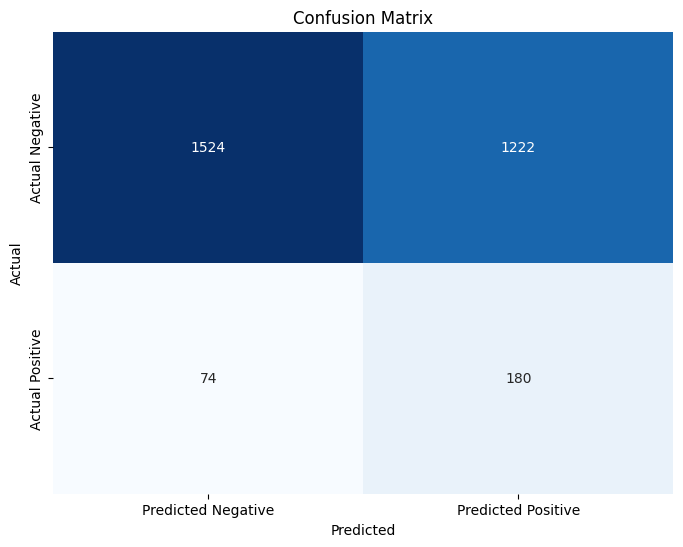

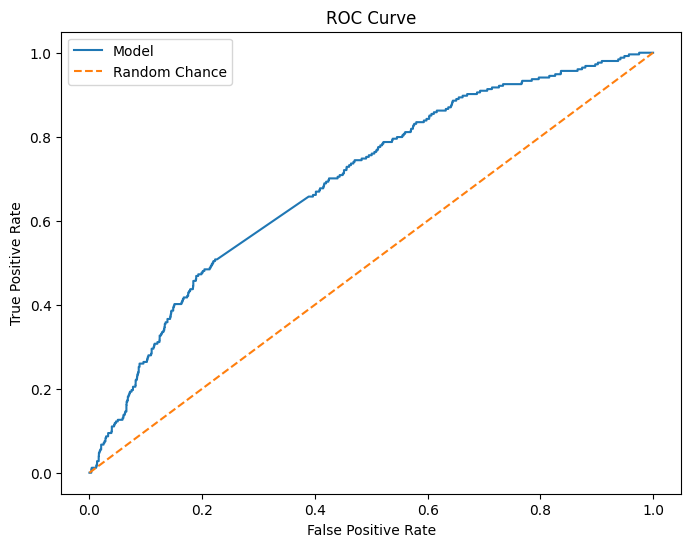

=== TEST METRICS ===
Accuracy: 0.568
ROC AUC Score: 0.6927341702461993
Confusion Matrix:
                  Predicted Negative  Predicted Positive
Actual Negative                1524                1222
Actual Positive                  74                 180
=== TRAINING METRICS ===
Train Accuracy: 0.5941111111111111
Train ROC AUC: 0.7747564851311471



In [9]:
model, scaler = train_logistic_regression(train_df, feature_columns)
predict_and_analyze_model(model, scaler, train_df, test_df, feature_columns)